In [1]:
import os
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv("master_df.csv",index_col=0)
data.rename(columns={'Zone':'Geographic Area'},inplace=True)

In [3]:
data.head()

,Country,Type,population,total_10,female_10,ratio_10,female_p_10,total_11,female_11,ratio_11,...,Grade,stat_type,Economic Zone,GDP,Area (km^2),Population,Longitude,Latitude,Geographic Area,GDP Quartile
0,Austria,(RU),8504850.0,561,84,65.96236265189863,0.1497326203208556,509,65,59.848204259922284,...,bachelor,Awarded,1,73751,83879,9027999,14.083917,47.624674,West,3
1,Germany,(RU),80716000.0,1142,217,14.148372069973735,0.19001751313485113,1632,256,20.21903959561921,...,master,Awarded,1,69338,357569,82719540,10.298018,51.246770,West,3
2,Greece,(RU),10816286.0,925,341,85.51918837944929,0.36864864864864866,1033,426,95.5041314551039,...,master,Awarded,2,41186,131957,10413982,22.720528,39.123935,South,1
3,Ireland,(RU),4593100.0,595,159,129.54213929590037,0.2672268907563025,529,138,115.17275913870807,...,master,Awarded,0,127623,84421,7185600,-8.008237,53.202471,North,4
4,Italy,(RU),60782668.0,2737,456,45.02928367672179,0.16660577274388016,2658,398,43.7295710678577,...,master,Awarded,1,58754,301340,58968501,12.078021,42.919447,South,2


In [4]:
data.loc[data.stat_type == "First Year Students"]

,Country,Type,population,total_10,female_10,ratio_10,female_p_10,total_11,female_11,ratio_11,...,Grade,stat_type,Economic Zone,GDP,Area (km^2),Population,Longitude,Latitude,Geographic Area,GDP Quartile
104,Turkey,(RU),83150000.0,10511,3731,126.41010222489476,0.3549614689373038,11057,3981,132.9765484064943,...,bachelor,First Year Students,2,44151,783562,85372377,35.116065,39.111747,South,1
105,UK,(RU),63705000.0,31120,5633,488.50168746566203,0.1810089974293059,29880,5080,469.0369672710149,...,bachelor,First Year Students,1,58906,244376,67596281,-2.902716,54.101937,North,2
106,Portugal,(RU),10276617.0,2150,234,209.21281779791929,0.10883720930232559,2146,235,208.82358464852783,...,bachelor,First Year Students,2,48758,92230,10639726,-8.053041,39.677508,South,1
107,Poland,(RU),38433600.0,19900,n.a.,517.7761125681695,n.a.,21001,n.a.,546.4229216102577,...,bachelor,First Year Students,2,49464,312696,38036118,19.295074,52.210934,East,2
108,Norway,(RU),5328212.0,820,135,153.89778034357494,0.16463414634146342,895,140,167.9737968384141,...,bachelor,First Year Students,0,104459,385207,5550203,16.779275,73.740391,North,4
109,Netherlands,(RU),16848600.0,889,104,52.76402787175195,0.11698537682789652,930,106,55.19746447776076,...,bachelor,First Year Students,0,78215,41865,18165000,5.516241,52.312298,West,4
110,Latvia,(RU),2001468.0,1608,n.a.,803.4102968421179,n.a.,1687,n.a.,842.8813251073711,...,bachelor,First Year Students,2,42501,64589,1842226,24.829261,56.816584,North,1
111,Italy,(RU),60782668.0,10167,1346,167.2680771433067,0.13238910199665585,10928,1485,179.78809354008612,...,bachelor,First Year Students,1,58754,301340,58968501,12.078021,42.919447,South,2
112,Spain,(RU),46464053.0,n.a.,n.a.,n.a.,n.a.,n.a.,n.a.,n.a.,...,bachelor,First Year Students,2,52779,505990,48797875,-3.614584,40.433502,South,2
113,Ireland,(RU),4593100.0,692,95,150.66077376934967,0.13728323699421965,819,144,178.3109446778864,...,bachelor,First Year Students,0,127623,84421,7185600,-8.008237,53.202471,North,4


In [39]:
for q in data['GDP Quartile'].unique():
    temp = data.loc[data['GDP Quartile'] == q]
    print(q)
    print(temp.Country.unique())

3
['Austria' 'Germany' 'Belgium' 'Finland' 'France']
1
['Greece' 'Latvia' 'Portugal' 'Romania' 'Turkey' 'Bulgaria' 'Estonia']
4
['Ireland' 'Netherlands' 'Norway' 'Switzerland' 'Denmark']
2
['Italy' 'Poland' 'Spain' 'UK' 'Czechia' 'Lithuania']


In [40]:
data['stat_type'].unique()

array(['Awarded', 'Students', 'First Year Students'], dtype=object)

In [41]:
type_data = "(RU)"
grade = 'bachelor'
stat_type = "Students"
cluster_variable = 'Economic Zone'

In [42]:
data = data.loc[(data.Type == type_data) & (data.Grade == grade) & (data.stat_type == stat_type)]

## Temporal trends of the percentage of female students in each country

In [43]:
def cleanup_df(data):
    data.replace('n.a.',pd.NA,inplace=True)
    data.replace('tbp',pd.NA,inplace=True)
    data.dropna(how='any',inplace=True)
    for column in data.columns:
        if column not in ['Country','Type','Grade','stat_type','Geographic Area','Economic Zone']:
            data[column] = data[column].astype(float).round(4)
            
    return data

In [44]:
data = cleanup_df(data)

In [45]:
def compute_temporal_trend(df,attribute='female_p'):

    result_df = df[['Country','Geographic Area','Economic Zone', 'GDP Quartile']].copy()
    for column in df.columns:
        if attribute in column:
            year = 2000 + int(column.split("_")[-1])
            result_df.loc[:,year] = df[column].values

    return result_df

In [46]:
data

,Country,Type,population,total_10,female_10,ratio_10,female_p_10,total_11,female_11,ratio_11,...,Grade,stat_type,Economic Zone,GDP,Area (km^2),Population,Longitude,Latitude,Geographic Area,GDP Quartile
32,Denmark,(RU),5627235.0,2071.0,226.0,368.0315,0.1091,2400.0,288.0,426.4972,...,bachelor,Students,0,76687.0,43094.0,5935619.0,9.8713,56.0822,North,4.0
33,Estonia,(RU),1313271.0,1415.0,329.0,1077.4623,0.2325,1477.0,302.0,1124.6727,...,bachelor,Students,2,48992.0,45335.0,1373101.0,25.8220,58.6557,North,1.0
34,Finland,(RU),5503297.0,10643.0,1601.0,1933.9316,0.1504,9888.0,1516.0,1796.7411,...,bachelor,Students,1,65060.0,338145.0,5603851.0,26.2418,64.9184,North,3.0
36,Germany,(RU),80716000.0,53339.0,8464.0,660.8231,0.1587,57828.0,9505.0,716.4379,...,bachelor,Students,1,69338.0,357569.0,82719540.0,10.2980,51.2468,West,3.0
38,Ireland,(RU),4593100.0,2403.0,354.0,523.1761,0.1473,2648.0,418.0,576.5169,...,bachelor,Students,0,127623.0,84421.0,7185600.0,-8.0082,53.2025,North,4.0
40,Latvia,(RU),2001468.0,4453.0,690.0,2224.8669,0.1550,4506.0,730.0,2251.3475,...,bachelor,Students,2,42501.0,64589.0,1842226.0,24.8293,56.8166,North,1.0
42,Netherlands,(RU),16848600.0,3568.0,362.0,211.7683,0.1015,3629.0,391.0,215.3888,...,bachelor,Students,0,78215.0,41865.0,18165000.0,5.5162,52.3123,West,4.0
43,Norway,(RU),5328212.0,3065.0,495.0,575.2399,0.1615,3335.0,550.0,625.9135,...,bachelor,Students,0,104459.0,385207.0,5550203.0,16.7793,73.7404,North,4.0
44,Poland,(RU),38433600.0,59928.0,6597.0,1559.2606,0.1101,56759.0,6280.0,1476.8068,...,bachelor,Students,2,49464.0,312696.0,38036118.0,19.2951,52.2109,East,2.0
45,Portugal,(RU),10276617.0,10056.0,1085.0,978.5321,0.1079,9557.0,1004.0,929.9753,...,bachelor,Students,2,48758.0,92230.0,10639726.0,-8.0530,39.6775,South,1.0


In [47]:
data[['female_p_21', 'Economic Zone', 'GDP', 'Population', 'GDP Quartile']].corr()

,female_p_21,Economic Zone,GDP,Population,GDP Quartile
female_p_21,1.000000,-0.173558,0.143424,-0.114066,0.052780
Economic Zone,-0.173558,1.000000,-0.866503,0.166076,-0.948216
GDP,0.143424,-0.866503,1.000000,-0.217619,0.849872
Population,-0.114066,0.166076,-0.217619,1.000000,-0.103397
GDP Quartile,0.052780,-0.948216,0.849872,-0.103397,1.000000


In [48]:
data = compute_temporal_trend(data)
tokeep = list(range(2010,2022)) + ['Country', cluster_variable]
data.drop(columns=[c for c in data.columns if c not in tokeep], inplace=True)

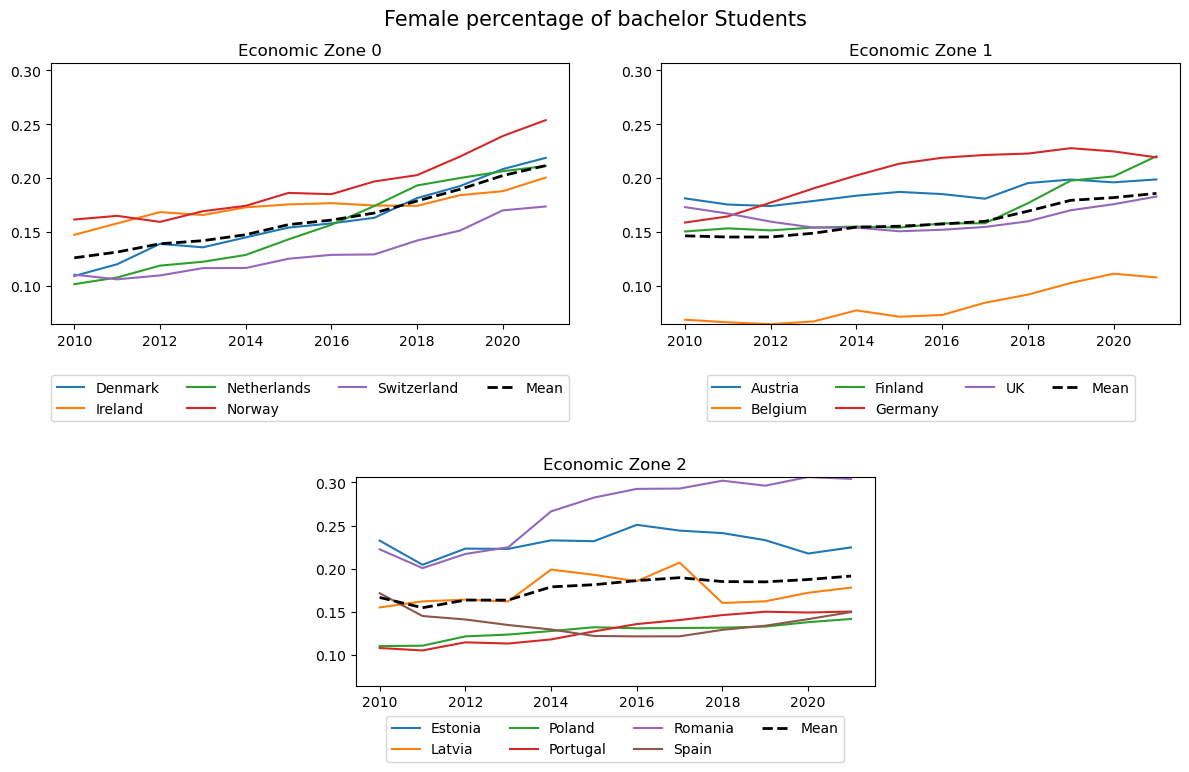

In [49]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import os
import pandas as pd

# Sample DataFrame setup
df_long = data.melt(id_vars=['Country', cluster_variable], var_name='Year', value_name='Value')

df_long['Year'] = df_long['Year'].astype(int)

# Define zones based on cluster variable
if cluster_variable == 'Geographic Area':
    zones = ['North', 'South', 'West', 'East']
elif cluster_variable == 'Economic Zone':
    zones = [0, 1, 2]
elif cluster_variable == 'GDP Quartile':
    zones = [1, 2, 3, 4]
else:
    zones = [] 

num_zones = len(zones)

y_min = df_long['Value'].min()
y_max = df_long['Value'].max()


# Create a gridspec for flexible layout
fig = plt.figure(figsize=(12, 8))

if num_zones == 3:
    gs = gridspec.GridSpec(2, 4, height_ratios=[1, 0.8])  # Adjust height ratios to make the second row smaller
    ax1 = fig.add_subplot(gs[0, :2])  # First plot in top left
    ax2 = fig.add_subplot(gs[0, 2:])  # Second plot in top right
    ax3 = fig.add_subplot(gs[1, 1:3])  # Third plot centered in second row
    axes = [ax1, ax2, ax3]
else:
    gs = gridspec.GridSpec(2, 2)
    axes = [fig.add_subplot(gs[i, j]) for i in range(2) for j in range(2)]  

for i, zone in enumerate(zones):
    ax = axes[i]
    zone_data = df_long[df_long[cluster_variable] == zone]
    
    for country, country_data in zone_data.groupby('Country'):
        ax.plot(country_data['Year'], country_data['Value'], label=country)

    mean_data = zone_data.groupby('Year')['Value'].mean().reset_index()
    
    ax.plot(mean_data['Year'], mean_data['Value'], label='Mean', color='black', linewidth=2, linestyle='--')
    
    ax.set_title(f'{cluster_variable} {zone}')
    ax.legend(loc='lower center', bbox_to_anchor=(0.5, -0.4), ncol=4)
    ax.set_ylim(y_min, y_max)

# Remove any empty axes if fewer than 4 zones
if len(zones) < 4:
    for j in range(len(zones), len(axes)):
        fig.delaxes(axes[j])

plt.suptitle(f"Female percentage of {grade} {stat_type}", size=15)
plt.tight_layout()
plt.savefig(os.path.join("plots", cluster_variable, f"plot_{stat_type}_{cluster_variable}_{type_data}_{grade}.png"))
plt.show()


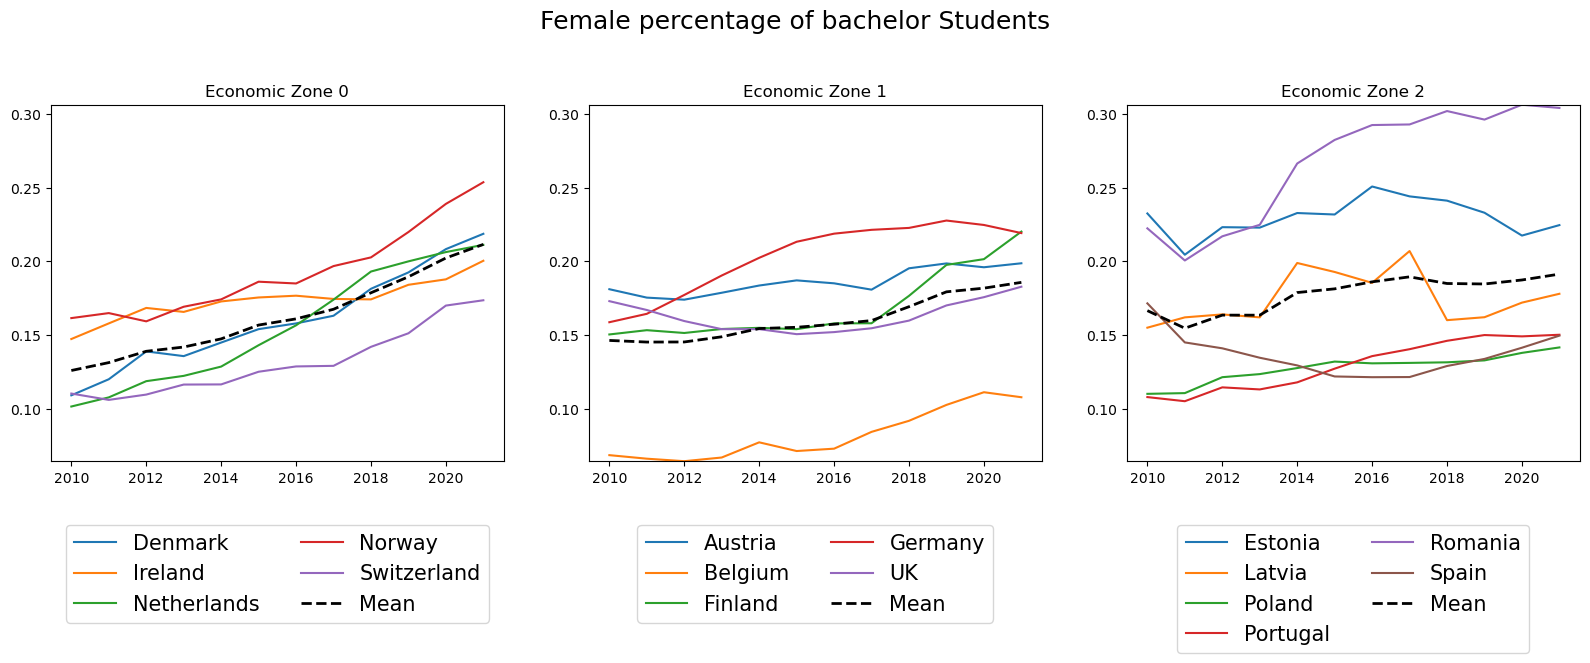

In [64]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import os
import pandas as pd

# Sample DataFrame setup (replace `data` with your actual dataset)
# Assuming 'data', 'cluster_variable', 'grade', 'stat_type', and 'type_data' are predefined
df_long = data.melt(id_vars=['Country', cluster_variable], var_name='Year', value_name='Value')
df_long['Year'] = df_long['Year'].astype(int)

# Define zones based on cluster variable
if cluster_variable == 'Geographic Area':
    zones = ['North', 'South', 'West', 'East']
elif cluster_variable == 'Economic Zone':
    zones = [0, 1, 2]
elif cluster_variable == 'GDP Quartile':
    zones = [1, 2, 3, 4]
else:
    zones = [] 

num_zones = len(zones)

# Determine global min and max for consistent y-axis scaling
y_min = df_long['Value'].min()
y_max = df_long['Value'].max()

# Create a gridspec for flexible layout
fig = plt.figure(figsize=(16, 7))  # Increased size for larger plots

if num_zones == 3:
    # Arrange all three plots in a single row
    gs = gridspec.GridSpec(1, 3)  # 1 row, 3 columns
    axes = [fig.add_subplot(gs[0, i]) for i in range(3)]  # Create axes for each column
else:
    gs = gridspec.GridSpec(2, 2)  # Default layout for other numbers of zones
    axes = [fig.add_subplot(gs[i, j]) for i in range(2) for j in range(2)]

# Plotting loop
for i, zone in enumerate(zones):
    ax = axes[i]
    zone_data = df_long[df_long[cluster_variable] == zone]
    
    # Plot each country's data
    for country, country_data in zone_data.groupby('Country'):
        ax.plot(country_data['Year'], country_data['Value'], label=country)
    
    # Add mean line for the cluster
    mean_data = zone_data.groupby('Year')['Value'].mean().reset_index()
    ax.plot(mean_data['Year'], mean_data['Value'], label='Mean', color='black', linewidth=2, linestyle='--')
    
    # Title, legend, and axis limits
    ax.set_title(f'{cluster_variable} {zone}')
    ax.set_ylim(y_min, y_max)
    
    # Adjust legend placement and columns
    
    ax.legend(
        loc='upper center',  # Position legend above the plot
        bbox_to_anchor=(0.5, -0.15),  # Adjust placement relative to the plot
        ncol=2,  # Reduce columns for better spacing
        fontsize=15  # Slightly smaller font size for compactness
    )

# Remove any empty axes if fewer than 4 zones
if len(zones) < 4:
    for j in range(len(zones), len(axes)):
        fig.delaxes(axes[j])

# Final adjustments
plt.suptitle(f"Female percentage of {grade} {stat_type}", size=18)  # Increased title size
plt.tight_layout(rect=[0, 0, 1, 0.95])  # Leave space for the title
os.makedirs(os.path.join("plots", cluster_variable), exist_ok=True)  # Ensure the directory exists
plt.savefig(os.path.join("plots", cluster_variable, f"plot_{stat_type}_{cluster_variable}_{type_data}_{grade}.png"))
plt.show()


In [50]:
'''
df_long = data.melt(id_vars=['Country', cluster_variable], var_name='Year', value_name='Value')

df_long['Year'] = df_long['Year'].astype(int)

if cluster_variable == 'Geographic Area':
    zones = ['North', 'South', 'West', 'East']
elif cluster_variable == 'Economic Zone':
    zones = [0, 1, 2]
elif cluster_variable == 'GDP Quartile':
    zones = [1, 2, 3, 4]
else:
    zones = [] 
    
#zones = df_long[cluster_variable].unique()
num_zones = len(zones)

rows, cols = 3, num_zones

y_min = df_long['Value'].min()
y_max = df_long['Value'].max()

fig, axes = plt.subplots(rows, cols, figsize=(6 * cols, 4 * rows), sharey=False)

axes = axes.flatten()

for i, zone in enumerate(zones):
    if i >= len(axes):
        break  
    ax = axes[i]
    zone_data = df_long[df_long[cluster_variable] == zone]
    
    for country, country_data in zone_data.groupby('Country'):
        ax.plot(country_data['Year'], country_data['Value'], label=country)

    mean_data = zone_data.groupby('Year')['Value'].mean().reset_index()
    
    ax.plot(mean_data['Year'], mean_data['Value'], label='Mean', color='black', linewidth=2, linestyle='--')
    
    
    ax.set_title(f'{cluster_variable} {zone}')
    ax.legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize='small')
    ax.set_ylim(y_min, y_max)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle(f"Female percentage of {grade} {stat_type}", size=15)
plt.tight_layout()
plt.savefig(os.path.join("plots", cluster_variable, f"plot_{cluster_variable}_{type_data}_{grade}_{stat_type}.png"))
plt.show()
'''

'\ndf_long = data.melt(id_vars=[\'Country\', cluster_variable], var_name=\'Year\', value_name=\'Value\')\n\ndf_long[\'Year\'] = df_long[\'Year\'].astype(int)\n\nif cluster_variable == \'Geographic Area\':\n    zones = [\'North\', \'South\', \'West\', \'East\']\nelif cluster_variable == \'Economic Zone\':\n    zones = [0, 1, 2]\nelif cluster_variable == \'GDP Quartile\':\n    zones = [1, 2, 3, 4]\nelse:\n    zones = [] \n    \n#zones = df_long[cluster_variable].unique()\nnum_zones = len(zones)\n\nrows, cols = 3, num_zones\n\ny_min = df_long[\'Value\'].min()\ny_max = df_long[\'Value\'].max()\n\nfig, axes = plt.subplots(rows, cols, figsize=(6 * cols, 4 * rows), sharey=False)\n\naxes = axes.flatten()\n\nfor i, zone in enumerate(zones):\n    if i >= len(axes):\n        break  \n    ax = axes[i]\n    zone_data = df_long[df_long[cluster_variable] == zone]\n    \n    for country, country_data in zone_data.groupby(\'Country\'):\n        ax.plot(country_data[\'Year\'], country_data[\'Value\'], l